In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scanpy as sc
from scipy.io import mmread
import anndata as ad

## 1. Load raw data

In [3]:
pwd

'/root/capsule/notebooks/retroseq'

In [5]:
mainfiledir = '/root/capsule/data/retroseq/'

genes = pd.read_csv(mainfiledir + 'genes.tsv', header=None).values[:, 0]
cellnames = pd.read_csv(mainfiledir + 'cells.tsv', header=None).values[:, 0]
metadata = pd.read_csv(mainfiledir + 'metadata.csv')
matrix = mmread(mainfiledir + 'retro_raw.mtx').tocsr()

print(f'Loaded {matrix.shape[0]} cells x {matrix.shape[1]} genes')

Loaded 1383 cells x 32245 genes


## 2. Subset to selected cells
Load the pre-computed list of 1100 kept cell names (see `00_a_generate_kept_cells.ipynb` for how this was created).

In [6]:
kept_cellnames = pd.read_csv(mainfiledir + 'kept_cells_retroseq.csv')['cell_name'].values
allcellskept = np.isin(cellnames, kept_cellnames)

metadata = metadata[allcellskept]
matrix = matrix[allcellskept]
cellnames = cellnames[allcellskept]
print(f'Kept {cellnames.shape[0]} cells')  # expected: 1100

Kept 1100 cells


## 3. Create AnnData object

In [7]:
adata = ad.AnnData(matrix)
adata.var_names = genes
adata.obs = metadata
adata.obs_names = cellnames
adata

/opt/conda/lib/python3.12/site-packages/anndata/_core/anndata.py:740: UserWarning: 
AnnData expects .obs.index to contain strings, but got values like:
    [0, 1, 3, 4, 6]

    Inferred to be: integer

  value_idx = self._prep_dim_index(value.index, attr)


AnnData object with n_obs × n_vars = 1100 × 32245
    obs: 'Unnamed: 0', 'exp_component_name', 'ar_id', 'exp_component_vendor_name', 'batch', 'batch_vendor_name', 'tube', 'tube_internal_name', 'tube_contents_nm', 'tube_contents_nm_from_vendor', 'tube_avg_size_bp', 'tube_input_fmol', 'r1_index', 'r2_index', 'index_sequence_pair', 'organism', 'reference_id', 'facs_container', 'sample_name', 'patched_cell_container', 'cell_name', 'cell_id', 'studies', 'hemisphere_name', 'sample_quantity_count', 'sample_quantity_pg', 'external_donor_name', 'age', 'species', 'gender', 'control', 'cell_prep_type', 'full_genotype', 'facs_population_plan', 'cre_line', 'reporter', 'injection_roi', 'injection_method', 'injection_materials', 'propagation_type', 'roi', 'patchseq_roi', 'medical_conditions', 'slice_min_pos', 'slice_max_pos', 'rna_amplification_set', 'rna_amplification', 'method', 'amp_date', 'pcr_cycles', 'percent_cdna_longer_than_400bp', 'rna_amplification_pass_fail', 'amplified_quantity_ng', 'load

## 4. Add injection-site annotation

In [8]:
# Load mouse ID → projection target mapping
proj_map = pd.read_csv(mainfiledir + 'mouse_projection_target.csv')
id_to_target = dict(zip(proj_map['ID'], proj_map['projection_target']))


adata.obs['injection_site'] = metadata['external_donor_name'].astype(int).map(id_to_target).values
adata.obs['injection_site'].value_counts()

injection_site
thalamus          528
cerebellum        210
spinal cord       188
frontal cortex    174
Name: count, dtype: int64

## 5. QC metrics

In [9]:
adata.var['mt'] = adata.var_names.str.startswith('mt-')
adata.var['ribo'] = adata.var_names.str.startswith(('Rps', 'Rpl'))
sc.pp.calculate_qc_metrics(adata, qc_vars=['mt', 'ribo'], inplace=True, log1p=True)

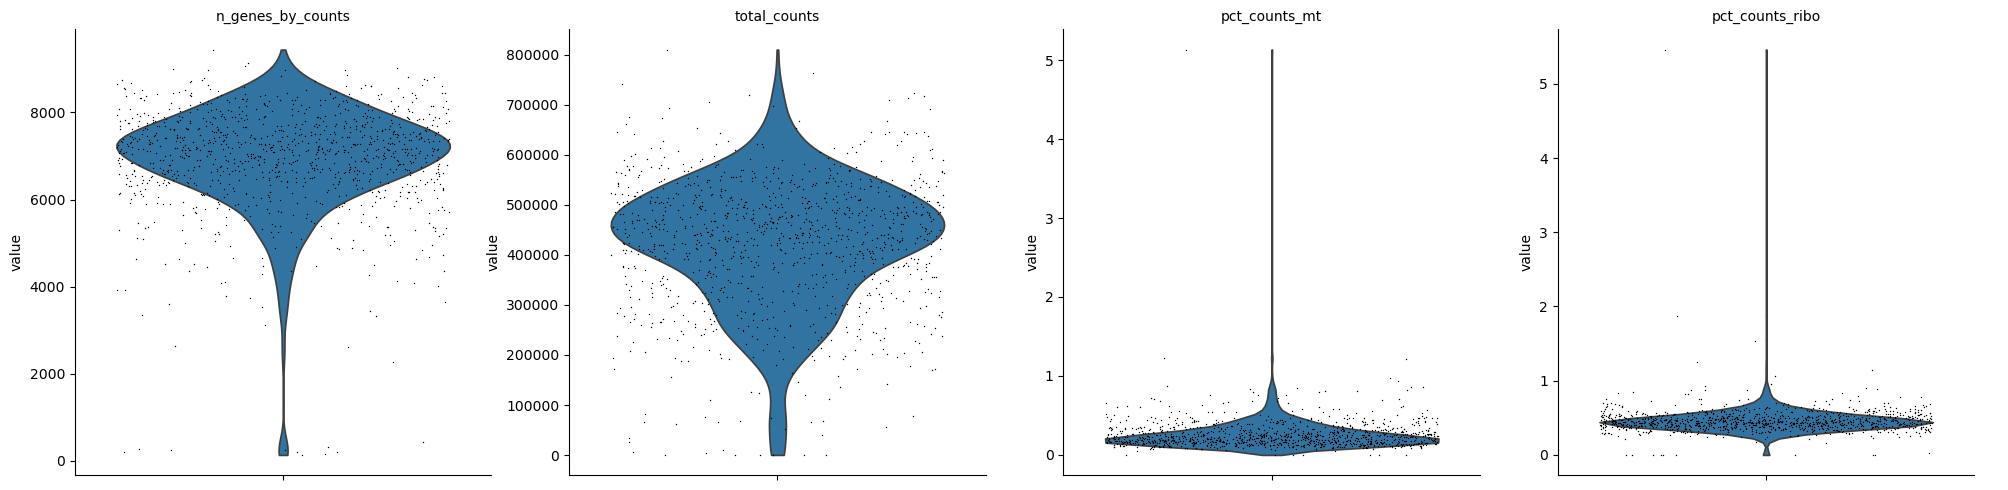

In [10]:
sc.pl.violin(
    adata,
    ['n_genes_by_counts', 'total_counts', 'pct_counts_mt', 'pct_counts_ribo'],
    jitter=0.4,
    multi_panel=True,
)

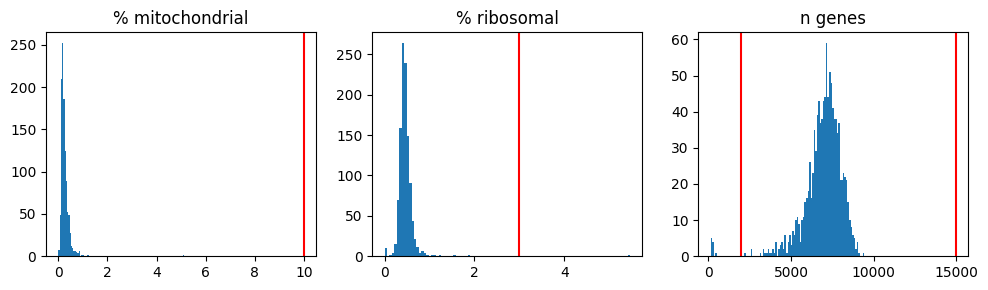

In [15]:
plt.figure(figsize=(10, 3))

plt.subplot(1, 3, 1)
plt.hist(adata.obs['pct_counts_mt'].values.flatten(), bins=100)
plt.axvline(10, color='red')
plt.title('% mitochondrial')

plt.subplot(1, 3, 2)
plt.hist(adata.obs['pct_counts_ribo'].values.flatten(), bins=100)
plt.axvline(3, color='red')
plt.title('% ribosomal')

plt.subplot(1, 3, 3)
plt.hist(adata.obs['n_genes_by_counts'].values.flatten(), bins=100)
plt.axvline(2000, color='red')
plt.axvline(15000, color='red')
plt.title('n genes')

plt.tight_layout()
plt.show()

## 6. Filter cells

In [11]:
mask = (
    (adata.obs['pct_counts_mt'] < 10) &
    (adata.obs['pct_counts_ribo'] < 3) &
    (adata.obs['n_genes_by_counts'].between(2000, 15000))
)

filtered_adata = adata[mask].copy()

print(f'Cells before filtering: {adata.n_obs}')
print(f'Cells after filtering:  {filtered_adata.n_obs}')

Cells before filtering: 1100
Cells after filtering:  1089


In [12]:
filtered_adata.obs['injection_site'].value_counts()

injection_site
thalamus          522
cerebellum        210
spinal cord       184
frontal cortex    173
Name: count, dtype: int64

In [13]:
filtered_adata.shape

(1089, 32245)

## 7. Save filtered AnnData

In [14]:
filtered_adata.obs['external_donor_name'] = filtered_adata.obs['external_donor_name'].astype('str')

savefilename = '/root/capsule/data/retroseq/retroseq_updated_filtered.h5ad'
filtered_adata.write_h5ad(savefilename)
print(f'Saved {filtered_adata.n_obs} cells to {savefilename}')

Saved 1089 cells to /root/capsule/data/retroseq/retroseq_updated_filtered.h5ad
